## Group 63 — Shadow-Model Membership-Inference Prototype

### Purpose
Investigate whether prediction outputs from a record-linkage model reveal
whether a particular record pair was used to train it.

### Main experiment
- Train one target model and ten shadow models using the same architecture
  and training settings.
- Split each model's source pool into 70% training and 30% held-out pairs.
- Collect predictions for balanced samples of training members and
  held-out non-members.
- Train membership-inference classifiers using outputs from five and
  ten shadow models.
- Evaluate both attacks against the same target examples using ROC AUC,
  accuracy, precision, recall, F1 and confusion matrices.

### Label definitions
- **Linkage label:** whether two records match.
- **Membership label:** whether a record pair was used to train the
  particular model being queried.

These labels represent different tasks and must not be confused.

### Scope and limitations
Membership is defined at the record-pair level. Individual record IDs
may overlap across data pools, so pair separation does not establish
entity-level independence.

The K=10 attack uses more training examples than K=5. The comparison
therefore measures both the increase in shadow models and the increase
in attack-training data.

Results describe this experiment and do not establish that the target
model is secure.

In [1]:
# Shared imports for model training, evaluation and saved-result checks.
from pathlib import Path
from datetime import datetime
import gc
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)

print("Imports ready.")
print("TensorFlow:", tf.__version__)

Imports ready.
TensorFlow: 2.13.1


In [2]:
def build_shadow_model(dim):
    """Build a fresh Siamese model, shared encoder and linkage head."""
    L = tf.keras.layers

    # Both records pass through the same encoder with shared weights.
    encoder_input = L.Input(shape=(dim,))
    hidden = L.Dense(
        50,
        activity_regularizer=tf.keras.regularizers.l1(0.01),
    )(encoder_input)
    hidden = L.LeakyReLU(alpha=0.01)(hidden)
    encoder = tf.keras.Model(
        encoder_input,
        L.Dense(dim, activation="relu")(hidden),
    )

    # Decoded pair representations are used by the Siamese training loss.
    decoder_input = L.Input(shape=(dim,))
    decoder = tf.keras.Model(
        decoder_input,
        L.Dense(dim, activation="sigmoid")(decoder_input),
    )

    left_input = L.Input(shape=(dim,))
    right_input = L.Input(shape=(dim,))
    paired_outputs = L.Concatenate()([
        decoder(encoder(left_input)),
        decoder(encoder(right_input)),
    ])
    siamese = tf.keras.Model(
        [left_input, right_input],
        paired_outputs,
    )

    def loss(labels, predictions):
        left = predictions[:, :dim]
        right = predictions[:, dim:]

        squared_distance = tf.reduce_sum(
            tf.square(left - right), axis=1
        )

        # Keep the square-root calculation away from zero.
        distance = tf.sqrt(
            tf.maximum(squared_distance, tf.keras.backend.epsilon())
        )

        # Flatten labels to prevent unintended broadcasting across pairs.
        labels = tf.reshape(tf.cast(labels, tf.float32), [-1])

        # This compares decoded outputs with each other, not with inputs.
        pair_difference_loss = tf.reduce_mean(
            tf.square(left - right), axis=1
        )

        # Linkage label 1 means a matching pair; 0 means a non-match.
        contrastive_loss = (
            labels * squared_distance
            + (1 - labels)
            * tf.square(tf.maximum(2.5 - distance, 0))
        )

        return tf.reduce_mean(
            pair_difference_loss + contrastive_loss
        )

    siamese.compile(optimizer="adam", loss=loss)

    # The head receives absolute differences between encoder outputs.
    # Its output is a linkage probability, not a membership probability.
    head = tf.keras.Sequential([
        L.Input(shape=(dim,)),
        L.Dense(64, activation="relu"),
        L.Dense(32, activation="relu"),
        L.Dense(1, activation="sigmoid"),
    ])
    head.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return siamese, encoder, head


print("Shared target/shadow model definition ready.")

Shared target/shadow model definition ready.


In [3]:
# Check separation between the target and shadow source pools.
# Membership is defined for record pairs, not individual record IDs.

def pair_keys(frame):
    """Represent each pair consistently, including reversed pairs."""
    return {
        tuple(sorted((a, b)))
        for a, b in frame[["uid1", "uid2"]].itertuples(
            index=False, name=None
        )
    }


target_pairs = pd.read_csv(
    Path("Datasets") / "target_train.csv",
    usecols=["uid1", "uid2"],
    dtype=str,
)
shadow_pairs = pd.read_csv(
    Path("Datasets") / "shadow_train.csv",
    usecols=["uid1", "uid2"],
    dtype=str,
)

assert not target_pairs.isna().any().any(), "Missing target record IDs"
assert not shadow_pairs.isna().any().any(), "Missing shadow record IDs"

shared_pairs = pair_keys(target_pairs) & pair_keys(shadow_pairs)
print("Shared target/shadow pairs:", len(shared_pairs))

assert not shared_pairs, (
    "Target and shadow pools share record pairs; review before training."
)

# Report individual-ID overlap separately from pair overlap.
for column in ["uid1", "uid2"]:
    shared_ids = set(target_pairs[column]) & set(shadow_pairs[column])
    print(f"Shared {column} IDs:", len(shared_ids))

print(
    "Pair-separation check passed. "
    "This does not establish individual-record separation."
)

Shared target/shadow pairs: 0
Shared uid1 IDs: 7140
Shared uid2 IDs: 7312
Pair-separation check passed. This does not establish individual-record separation.


In [5]:
# Experiment settings.
# Default: review the completed experiment without retraining.
TRAIN_NEW_RUN = False

# Completed run used when TRAIN_NEW_RUN is False.
SAVED_RUN = Path("k_runs") / "main_20260920_230533"

# Settings used for the completed full experiment.
EXPERIMENT_SEED = 2026
SIAMESE_EPOCHS = 30
HEAD_EPOCHS = 20
BATCH_SIZE = 256
SHADOW_COUNTS = (5, 10)
TRAIN_FRACTION = 0.70
MEMBER_QUERY_FRACTION = 0.30

# Reload verification requires the original embeddings.
VERIFY_MODEL_RELOAD = False

if TRAIN_NEW_RUN:
    print("Selected mode: train a new target and ten shadow models.")
else:
    assert SAVED_RUN.is_dir(), (
        f"Saved experiment not found: {SAVED_RUN.resolve()}"
    )
    print("Selected mode: review saved results.")
    print("Saved experiment:", SAVED_RUN.resolve())

Selected mode: review saved results.
Saved experiment: C:\Users\fayya\OneDrive\Documents\GitHub\COMP3850\Group-63-COMP3850\k_runs\main_20260920_230533


In [6]:
# Train a new target only when explicitly enabled.
# Otherwise, load the completed target's saved query outputs.

if not TRAIN_NEW_RUN:
    experiment_dir = SAVED_RUN
    target_dir = experiment_dir / "target"

    target_outputs = pd.read_csv(
        target_dir / "membership_outputs.csv"
    )

    print("Loaded saved target outputs:", len(target_outputs))
    print("Experiment:", experiment_dir.resolve())

else:
    # Validate source embeddings and labels before creating a new run.
    target_x1 = np.load(
        "Embeddings/x1_target_train.npy", allow_pickle=False
    )
    target_x2 = np.load(
        "Embeddings/x2_target_train.npy", allow_pickle=False
    )
    target_y = np.load(
        "Embeddings/y_target_train.npy", allow_pickle=False
    )

    assert target_y.ndim == 1, "Target labels must be one-dimensional"
    assert target_x1.shape == target_x2.shape == (len(target_y), 768)
    assert np.isfinite(target_x1).all()
    assert np.isfinite(target_x2).all()
    assert np.isin(target_y, [0, 1]).all()

    target_csv = pd.read_csv(
        "Datasets/target_train.csv",
        dtype={"uid1": str, "uid2": str},
    )
    assert len(target_csv) == len(target_y)
    assert np.array_equal(target_csv["label"].to_numpy(), target_y)
    assert not target_csv[["uid1", "uid2"]].isna().any().any()

    # Split by pair; all listed training pairs are used for optimisation.
    target_train_idx, target_heldout_idx = train_test_split(
        np.arange(len(target_y)),
        test_size=round(1.0 - TRAIN_FRACTION, 10),
        stratify=target_y,
        random_state=EXPERIMENT_SEED,
    )

    assert pair_keys(target_csv.iloc[target_train_idx]).isdisjoint(
        pair_keys(target_csv.iloc[target_heldout_idx])
    ), "Duplicate pairs cross the target split; review before training."

    # A new directory preserves all previous experiment results.
    experiment_dir = Path("k_runs") / (
        "main_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    )
    experiment_dir.mkdir(parents=True, exist_ok=False)

    config = {
        "membership_unit": "record_pair",
        "architecture": "siamese_encoder_plus_classification_head",
        "shadow_counts": list(SHADOW_COUNTS),
        "seed": EXPERIMENT_SEED,
        "train_fraction": TRAIN_FRACTION,
        "member_query_fraction": MEMBER_QUERY_FRACTION,
        "siamese_epochs": SIAMESE_EPOCHS,
        "head_epochs": HEAD_EPOCHS,
        "batch_size": BATCH_SIZE,
    }
    (experiment_dir / "config.json").write_text(
        json.dumps(config, indent=2),
        encoding="utf-8",
    )

    target_dir = experiment_dir / "target"
    target_dir.mkdir()

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(EXPERIMENT_SEED)

    target_siamese, target_encoder, target_head = build_shadow_model(
        target_x1.shape[1]
    )

    # Train the shared encoder through the Siamese pairwise objective.
    target_sa_history = target_siamese.fit(
        [target_x1[target_train_idx], target_x2[target_train_idx]],
        target_y[target_train_idx],
        epochs=SIAMESE_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=2,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )
    assert np.isfinite(target_sa_history.history["loss"]).all()

    def target_features(indices):
        """Return absolute differences between encoded record pairs."""
        return np.abs(
            target_encoder.predict(
                target_x1[indices],
                batch_size=BATCH_SIZE,
                verbose=0,
            )
            - target_encoder.predict(
                target_x2[indices],
                batch_size=BATCH_SIZE,
                verbose=0,
            )
        )

    # Train the linkage head on the same training members.
    target_head_history = target_head.fit(
        target_features(target_train_idx),
        target_y[target_train_idx],
        epochs=HEAD_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=2,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()],
    )
    assert np.isfinite(target_head_history.history["loss"]).all()

    # Fix balanced target queries for both K=5 and K=10 evaluations.
    rng = np.random.default_rng(EXPERIMENT_SEED)
    n_queries = min(
        int(MEMBER_QUERY_FRACTION * len(target_train_idx)),
        len(target_heldout_idx),
    )
    assert n_queries > 0, "No membership queries selected"

    target_members = rng.choice(
        target_train_idx, n_queries, replace=False
    )
    target_nonmembers = rng.choice(
        target_heldout_idx, n_queries, replace=False
    )
    query_idx = np.concatenate([target_members, target_nonmembers])

    target_scores = target_head.predict(
        target_features(query_idx),
        batch_size=BATCH_SIZE,
        verbose=0,
    ).ravel()
    assert np.isfinite(target_scores).all()

    target_outputs = pd.DataFrame({
        "embedding_row": query_idx,
        "p_match": target_scores,
        "linkage_label": target_y[query_idx],
        "membership": np.r_[
            np.ones(n_queries, dtype=int),
            np.zeros(n_queries, dtype=int),
        ],
    })

    # Save predictions, split assignments, models and training histories.
    target_outputs.to_csv(
        target_dir / "membership_outputs.csv", index=False
    )
    np.savez(
        target_dir / "split_indices.npz",
        train=target_train_idx,
        heldout=target_heldout_idx,
        members=target_members,
        nonmembers=target_nonmembers,
    )
    target_encoder.save(str(target_dir / "encoder.keras"))
    target_head.save(str(target_dir / "linkage_head.keras"))

    pd.DataFrame(target_sa_history.history).to_csv(
        target_dir / "siamese_history.csv", index=False
    )
    pd.DataFrame(target_head_history.history).to_csv(
        target_dir / "head_history.csv", index=False
    )

    print("Target complete:", experiment_dir.resolve())
    print("Training pairs:", len(target_train_idx))
    print("Held-out pairs:", len(target_heldout_idx))
    print("Membership queries per class:", n_queries)

Loaded saved target outputs: 13440
Experiment: C:\Users\fayya\OneDrive\Documents\GitHub\COMP3850\Group-63-COMP3850\k_runs\main_20260920_230533


In [7]:
# Train the shadow models only for a new experiment.
# Saved-results mode reads the existing combined predictions.

if not TRAIN_NEW_RUN:
    main_shadow_outputs = pd.read_csv(
        experiment_dir / "combined_shadow_outputs.csv"
    )

    print(
        "Loaded saved shadow models:",
        main_shadow_outputs["shadow_id"].nunique(),
    )
    print("Loaded membership examples:", len(main_shadow_outputs))

else:
    # Load and validate the shadow source pool.
    shadow_x1 = np.load(
        "Embeddings/x1_shadow_train.npy", allow_pickle=False
    )
    shadow_x2 = np.load(
        "Embeddings/x2_shadow_train.npy", allow_pickle=False
    )
    shadow_y = np.load(
        "Embeddings/y_shadow_train.npy", allow_pickle=False
    )

    shadow_csv = pd.read_csv(
        "Datasets/shadow_train.csv",
        dtype={"uid1": str, "uid2": str},
    )

    assert shadow_y.ndim == 1
    assert shadow_x1.shape == shadow_x2.shape == (len(shadow_y), 768)
    assert np.isfinite(shadow_x1).all()
    assert np.isfinite(shadow_x2).all()
    assert np.isin(shadow_y, [0, 1]).all()
    assert len(shadow_csv) == len(shadow_y)
    assert np.array_equal(shadow_csv["label"].to_numpy(), shadow_y)
    assert not shadow_csv[["uid1", "uid2"]].isna().any().any()
    assert pair_keys(shadow_csv).isdisjoint(pair_keys(target_csv)), (
        "Target and shadow pools contain shared record pairs."
    )

    total_shadows = max(SHADOW_COUNTS)

    # Validate every planned split before starting model training.
    planned_splits = {}

    for sid in range(1, total_shadows + 1):
        train_ids, heldout_ids = train_test_split(
            np.arange(len(shadow_y)),
            test_size=round(1.0 - TRAIN_FRACTION, 10),
            stratify=shadow_y,
            random_state=EXPERIMENT_SEED + sid,
        )

        assert pair_keys(shadow_csv.iloc[train_ids]).isdisjoint(
            pair_keys(shadow_csv.iloc[heldout_ids])
        ), f"Shadow {sid}: duplicate pairs cross the split."

        planned_splits[sid] = (train_ids, heldout_ids)

    collected_outputs = []

    for sid in range(1, total_shadows + 1):
        model_dir = experiment_dir / f"shadow_{sid}"
        complete_marker = model_dir / "complete.json"
        predictions_path = model_dir / "membership_outputs.csv"

        # Allows this cell to resume within the same active experiment.
        if complete_marker.exists():
            required_files = [
                "membership_outputs.csv",
                "split_indices.npz",
                "encoder.keras",
                "linkage_head.keras",
                "siamese_history.csv",
                "head_history.csv",
            ]
            assert all(
                (model_dir / name).is_file()
                for name in required_files
            ), f"Shadow {sid}: completed run has missing files."

            collected_outputs.append(pd.read_csv(predictions_path))
            print(
                f"Shadow {sid}/{total_shadows}: "
                "loaded completed outputs."
            )
            continue

        model_dir.mkdir(parents=True, exist_ok=True)
        seed = EXPERIMENT_SEED + sid
        train_ids, heldout_ids = planned_splits[sid]

        # Sample equally many training members and held-out non-members.
        rng = np.random.default_rng(seed)
        count = min(
            int(MEMBER_QUERY_FRACTION * len(train_ids)),
            len(heldout_ids),
        )
        assert count > 0, f"Shadow {sid}: no membership queries"

        member_ids = rng.choice(train_ids, count, replace=False)
        nonmember_ids = rng.choice(heldout_ids, count, replace=False)

        np.savez(
            model_dir / "split_indices.npz",
            train=train_ids,
            heldout=heldout_ids,
            members=member_ids,
            nonmembers=nonmember_ids,
        )

        # Initialise fresh weights for each shadow model.
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(seed)

        shadow_siamese, shadow_encoder, shadow_head = (
            build_shadow_model(shadow_x1.shape[1])
        )

        print(f"\nSHADOW {sid}/{total_shadows}: encoder training")
        sa_history = shadow_siamese.fit(
            [shadow_x1[train_ids], shadow_x2[train_ids]],
            shadow_y[train_ids],
            epochs=SIAMESE_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=2,
            callbacks=[tf.keras.callbacks.TerminateOnNaN()],
        )
        assert np.isfinite(sa_history.history["loss"]).all()

        def shadow_features(indices):
            """Return absolute differences between encoded records."""
            return np.abs(
                shadow_encoder.predict(
                    shadow_x1[indices],
                    batch_size=BATCH_SIZE,
                    verbose=0,
                )
                - shadow_encoder.predict(
                    shadow_x2[indices],
                    batch_size=BATCH_SIZE,
                    verbose=0,
                )
            )

        print(f"SHADOW {sid}/{total_shadows}: linkage-head training")
        head_history = shadow_head.fit(
            shadow_features(train_ids),
            shadow_y[train_ids],
            epochs=HEAD_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=2,
            callbacks=[tf.keras.callbacks.TerminateOnNaN()],
        )
        assert np.isfinite(head_history.history["loss"]).all()

        query_ids = np.concatenate([member_ids, nonmember_ids])
        probabilities = shadow_head.predict(
            shadow_features(query_ids),
            batch_size=BATCH_SIZE,
            verbose=0,
        ).ravel()
        assert np.isfinite(probabilities).all()

        rows = pd.DataFrame({
            "shadow_id": sid,
            "embedding_row": query_ids,
            "p_match": probabilities,
            "linkage_label": shadow_y[query_ids],
            "membership": np.r_[
                np.ones(count, dtype=int),
                np.zeros(count, dtype=int),
            ],
        })

        # Save all evidence before marking this shadow as complete.
        rows.to_csv(predictions_path, index=False)
        pd.DataFrame(sa_history.history).to_csv(
            model_dir / "siamese_history.csv", index=False
        )
        pd.DataFrame(head_history.history).to_csv(
            model_dir / "head_history.csv", index=False
        )
        shadow_encoder.save(str(model_dir / "encoder.keras"))
        shadow_head.save(str(model_dir / "linkage_head.keras"))

        complete_marker.write_text(
            json.dumps(
                {"shadow_id": sid, "seed": seed, "status": "complete"},
                indent=2,
            ),
            encoding="utf-8",
        )
        collected_outputs.append(rows)

        del shadow_siamese, shadow_encoder, shadow_head
        gc.collect()

    main_shadow_outputs = pd.concat(
        collected_outputs, ignore_index=True
    )
    main_shadow_outputs.to_csv(
        experiment_dir / "combined_shadow_outputs.csv",
        index=False,
    )

    print("\nCompleted shadow models:", total_shadows)
    print(
        main_shadow_outputs.groupby(
            ["shadow_id", "membership"]
        ).size()
    )
    print("Saved to:", experiment_dir.resolve())

Loaded saved shadow models: 10
Loaded membership examples: 134400



K=5 confusion matrix:
[[1802 4918]
 [1429 5291]]

K=10 confusion matrix:
[[1786 4934]
 [1411 5309]]


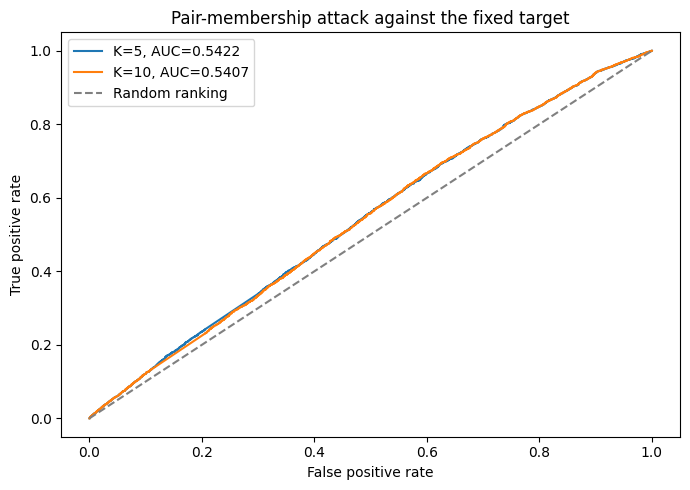


Saved metrics verified; no result files overwritten.

Attack comparison:
 K  attack_training_examples  accuracy  precision   recall       f1  roc_auc
 5                     67200  0.527753   0.518268 0.787351 0.625081 0.542242
10                    134400  0.527902   0.518305 0.790030 0.625951 0.540738

Experiment: C:\Users\fayya\OneDrive\Documents\GitHub\COMP3850\Group-63-COMP3850\k_runs\main_20260920_230533


In [8]:
# Compare membership attacks using the selected experiment.
# Saved-results mode reads predictions without fitting or overwriting models.

evaluation_dir = experiment_dir / "attack_evaluation"


def membership_features(frame):
    """Derive attack features only from linkage prediction probabilities."""
    p = np.clip(frame["p_match"].to_numpy(), 1e-7, 1 - 1e-7)
    confidence = np.maximum(p, 1 - p)
    entropy = -(p * np.log(p) + (1 - p) * np.log(1 - p))
    return np.column_stack([p, confidence, entropy])


shadows = main_shadow_outputs
target = target_outputs

assert set(shadows["shadow_id"]) == set(
    range(1, max(SHADOW_COUNTS) + 1)
)
assert not shadows.duplicated(["shadow_id", "embedding_row"]).any()
assert not target["embedding_row"].duplicated().any()

for frame in (shadows, target):
    assert not frame[["p_match", "membership"]].isna().any().any()
    assert frame["p_match"].between(0, 1).all()
    assert set(frame["membership"]) == {0, 1}

if TRAIN_NEW_RUN:
    evaluation_dir.mkdir(parents=True, exist_ok=False)
    prediction_table = target.copy()

    for k in SHADOW_COUNTS:
        training = shadows.loc[shadows["shadow_id"] <= k]

        # Target examples are never used to fit the attack or scaler.
        attack = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000, random_state=42),
        )
        attack.fit(
            membership_features(training),
            training["membership"],
        )

        scores = attack.predict_proba(
            membership_features(target)
        )[:, 1]

        prediction_table[f"membership_score_K{k}"] = scores
        prediction_table[f"predicted_membership_K{k}"] = (
            scores >= 0.5
        ).astype(int)

        joblib.dump(attack, evaluation_dir / f"attack_K{k}.joblib")

    prediction_table.to_csv(
        evaluation_dir / "target_attack_predictions.csv",
        index=False,
    )

    settings = {
        "features": [
            "p_match",
            "max_class_probability",
            "binary_entropy",
        ],
        "attack": "StandardScaler + LogisticRegression",
        "threshold": 0.5,
        "membership_unit": "pair",
        "target_used_for_attack_fitting": False,
        "comparison": list(SHADOW_COUNTS),
        "limitation": "Individual record IDs overlap across data pools.",
    }
    (evaluation_dir / "evaluation_settings.json").write_text(
        json.dumps(settings, indent=2),
        encoding="utf-8",
    )

else:
    prediction_table = pd.read_csv(
        evaluation_dir / "target_attack_predictions.csv"
    )

    # Confirm saved attack predictions belong to these target queries.
    assert np.array_equal(
        prediction_table["embedding_row"].to_numpy(),
        target["embedding_row"].to_numpy(),
    ), "Saved attack rows do not match the selected target."

    assert np.array_equal(
        prediction_table["membership"].to_numpy(),
        target["membership"].to_numpy(),
    ), "Saved membership labels do not match the target."

    np.testing.assert_allclose(
        prediction_table["p_match"].to_numpy(),
        target["p_match"].to_numpy(),
        rtol=1e-6,
        atol=1e-8,
    )

# Recalculate metrics in either mode using the same target labels.
y_target_membership = prediction_table["membership"].to_numpy()
results = []

plt.figure(figsize=(7, 5))

for k in SHADOW_COUNTS:
    scores = prediction_table[f"membership_score_K{k}"].to_numpy()
    predictions = prediction_table[
        f"predicted_membership_K{k}"
    ].to_numpy()

    assert np.isfinite(scores).all()
    assert ((scores >= 0) & (scores <= 1)).all()
    assert np.array_equal(
        predictions, (scores >= 0.5).astype(int)
    ), f"K={k}: predictions do not match the fixed threshold."

    matrix = confusion_matrix(
        y_target_membership, predictions, labels=[0, 1]
    )

    metrics = {
        "K": k,
        "attack_training_examples": int(
            (shadows["shadow_id"] <= k).sum()
        ),
        "target_evaluation_examples": len(prediction_table),
        "membership_threshold": 0.5,
        "accuracy": float(
            accuracy_score(y_target_membership, predictions)
        ),
        "precision": float(
            precision_score(
                y_target_membership, predictions, zero_division=0
            )
        ),
        "recall": float(
            recall_score(
                y_target_membership, predictions, zero_division=0
            )
        ),
        "f1": float(
            f1_score(
                y_target_membership, predictions, zero_division=0
            )
        ),
        "roc_auc": float(
            roc_auc_score(y_target_membership, scores)
        ),
        "true_negative": int(matrix[0, 0]),
        "false_positive": int(matrix[0, 1]),
        "false_negative": int(matrix[1, 0]),
        "true_positive": int(matrix[1, 1]),
    }
    results.append(metrics)

    fpr, tpr, thresholds = roc_curve(y_target_membership, scores)

    if TRAIN_NEW_RUN:
        pd.DataFrame({
            "false_positive_rate": fpr,
            "true_positive_rate": tpr,
            "threshold": thresholds,
        }).to_csv(evaluation_dir / f"roc_K{k}.csv", index=False)

    plt.plot(
        fpr, tpr,
        label=f"K={k}, AUC={metrics['roc_auc']:.4f}",
    )
    print(f"\nK={k} confusion matrix:\n{matrix}")

plt.plot(
    [0, 1], [0, 1], "--", color="grey", label="Random ranking"
)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Pair-membership attack against the fixed target")
plt.legend()
plt.tight_layout()

if TRAIN_NEW_RUN:
    plt.savefig(evaluation_dir / "target_attack_ROC.png", dpi=180)

plt.show()

summary = pd.DataFrame(results)

if TRAIN_NEW_RUN:
    summary.to_csv(evaluation_dir / "K_comparison.csv", index=False)
else:
    # Check recalculated metrics against the original saved summary.
    saved_summary = pd.read_csv(
        evaluation_dir / "K_comparison.csv"
    ).set_index("K")
    metric_columns = ["accuracy", "precision", "recall", "f1", "roc_auc"]

    np.testing.assert_allclose(
        summary.set_index("K").loc[
            list(SHADOW_COUNTS), metric_columns
        ].to_numpy(),
        saved_summary.loc[
            list(SHADOW_COUNTS), metric_columns
        ].to_numpy(),
        rtol=1e-6,
        atol=1e-8,
    )
    print("\nSaved metrics verified; no result files overwritten.")

print("\nAttack comparison:")
print(summary[
    ["K", "attack_training_examples", "accuracy",
     "precision", "recall", "f1", "roc_auc"]
].to_string(index=False))

print("\nExperiment:", experiment_dir.resolve())

In [9]:
# Check saved membership assignments for the target and every shadow.
# These checks establish row-index separation, not entity independence.

audit_rows = []
model_names = ["target"] + [
    f"shadow_{sid}" for sid in range(1, max(SHADOW_COUNTS) + 1)
]

for name in model_names:
    model_dir = experiment_dir / name
    predictions = pd.read_csv(
        model_dir / "membership_outputs.csv"
    )

    with np.load(
        model_dir / "split_indices.npz",
        allow_pickle=False,
    ) as saved:
        splits = {
            key: saved[key].copy()
            for key in ["train", "heldout", "members", "nonmembers"]
        }

    # Reject duplicate or invalid row indices in the saved split arrays.
    for key, indices in splits.items():
        assert indices.ndim == 1, f"{name}: {key} must be 1D"
        assert np.issubdtype(indices.dtype, np.integer), (
            f"{name}: {key} contains non-integer indices"
        )
        assert (indices >= 0).all(), f"{name}: negative indices"
        assert len(np.unique(indices)) == len(indices), (
            f"{name}: duplicate indices in {key}"
        )

    train_ids = set(splits["train"])
    heldout_ids = set(splits["heldout"])
    members = set(splits["members"])
    nonmembers = set(splits["nonmembers"])

    assert train_ids.isdisjoint(heldout_ids), (
        f"{name}: training/held-out overlap"
    )
    assert members <= train_ids, (
        f"{name}: a member was not in the training split"
    )
    assert nonmembers <= heldout_ids, (
        f"{name}: a non-member was not held out"
    )
    assert members.isdisjoint(nonmembers), (
        f"{name}: conflicting membership assignments"
    )
    assert len(members) == len(nonmembers) > 0, (
        f"{name}: membership queries are not balanced"
    )

    # Check prediction rows and their membership labels.
    required = ["embedding_row", "p_match", "membership"]
    assert not predictions[required].isna().any().any(), (
        f"{name}: missing prediction values"
    )
    assert not predictions["embedding_row"].duplicated().any(), (
        f"{name}: duplicate prediction rows"
    )
    assert set(predictions["membership"]) == {0, 1}, (
        f"{name}: invalid membership labels"
    )
    assert predictions["p_match"].between(0, 1).all(), (
        f"{name}: invalid linkage probabilities"
    )

    predicted_members = set(
        predictions.loc[
            predictions["membership"] == 1, "embedding_row"
        ]
    )
    predicted_nonmembers = set(
        predictions.loc[
            predictions["membership"] == 0, "embedding_row"
        ]
    )

    assert predicted_members == members, (
        f"{name}: member predictions differ from saved query indices"
    )
    assert predicted_nonmembers == nonmembers, (
        f"{name}: non-member predictions differ from saved query indices"
    )
    assert len(predictions) == len(members) + len(nonmembers)

    audit_rows.append({
        "model": name,
        "training_pairs": len(train_ids),
        "heldout_pairs": len(heldout_ids),
        "member_queries": len(members),
        "nonmember_queries": len(nonmembers),
        "membership_checks": "passed",
    })

audit = pd.DataFrame(audit_rows)

# Preserve the original report when reviewing an existing experiment.
if TRAIN_NEW_RUN:
    audit.to_csv(
        experiment_dir / "membership_audit.csv",
        index=False,
    )

print(audit.to_string(index=False))
print("\nMembership checks passed for all selected models.")

if not TRAIN_NEW_RUN:
    print("Saved-results mode: original audit file left unchanged.")

    model  training_pairs  heldout_pairs  member_queries  nonmember_queries membership_checks
   target           22400           9600            6720               6720            passed
 shadow_1           22400           9600            6720               6720            passed
 shadow_2           22400           9600            6720               6720            passed
 shadow_3           22400           9600            6720               6720            passed
 shadow_4           22400           9600            6720               6720            passed
 shadow_5           22400           9600            6720               6720            passed
 shadow_6           22400           9600            6720               6720            passed
 shadow_7           22400           9600            6720               6720            passed
 shadow_8           22400           9600            6720               6720            passed
 shadow_9           22400           9600            6720    

In [10]:
# Optional: reload models and reproduce their saved predictions.
# With verification disabled, display the historical report only.

reload_report_path = experiment_dir / "reload_checks.csv"

if not VERIFY_MODEL_RELOAD:
    print("Live model-reload verification is disabled.")

    if reload_report_path.is_file():
        reload_report = pd.read_csv(reload_report_path)
        print("\nHistorical verification report from this experiment:")
        print(reload_report.to_string(index=False))
        print("\nThese checks were not rerun in this execution.")
    else:
        print("No saved reload-verification report is available.")

else:
    reload_results = []
    model_names = ["target"] + [
        f"shadow_{sid}" for sid in range(1, max(SHADOW_COUNTS) + 1)
    ]

    for name in model_names:
        model_dir = experiment_dir / name
        saved_predictions = pd.read_csv(
            model_dir / "membership_outputs.csv"
        )

        # Check a reproducible sample from both membership classes.
        class_counts = saved_predictions["membership"].value_counts()
        assert set(class_counts.index) == {0, 1}
        sample_count = min(32, int(class_counts.min()))

        sample = saved_predictions.groupby(
            "membership", group_keys=False
        ).sample(n=sample_count, random_state=42)

        indices = sample["embedding_row"].to_numpy(dtype=int)
        source = "target" if name == "target" else "shadow"

        # Memory mapping avoids loading the full arrays into RAM.
        left = np.load(
            f"Embeddings/x1_{source}_train.npy",
            mmap_mode="r",
            allow_pickle=False,
        )
        right = np.load(
            f"Embeddings/x2_{source}_train.npy",
            mmap_mode="r",
            allow_pickle=False,
        )
        assert left.shape == right.shape
        assert ((indices >= 0) & (indices < len(left))).all()

        encoder_check = tf.keras.models.load_model(
            model_dir / "encoder.keras",
            compile=False,
        )
        head_check = tf.keras.models.load_model(
            model_dir / "linkage_head.keras",
            compile=False,
        )

        features = np.abs(
            encoder_check.predict(left[indices], verbose=0)
            - encoder_check.predict(right[indices], verbose=0)
        )
        reproduced = head_check.predict(
            features, verbose=0
        ).ravel()

        np.testing.assert_allclose(
            reproduced,
            sample["p_match"].to_numpy(),
            rtol=1e-4,
            atol=1e-5,
            err_msg=f"{name}: reloaded predictions differ",
        )

        reload_results.append({
            "model": name,
            "examples_checked": len(sample),
            "reload_check": "passed",
        })

        del encoder_check, head_check, left, right, features
        gc.collect()

    # Verify both attack pipelines against all saved target scores.
    saved_attacks = pd.read_csv(
        evaluation_dir / "target_attack_predictions.csv"
    )

    for k in SHADOW_COUNTS:
        attack_check = joblib.load(
            evaluation_dir / f"attack_K{k}.joblib"
        )
        reproduced = attack_check.predict_proba(
            membership_features(saved_attacks)
        )[:, 1]

        np.testing.assert_allclose(
            reproduced,
            saved_attacks[f"membership_score_K{k}"].to_numpy(),
            rtol=1e-6,
            atol=1e-8,
            err_msg=f"Attack K={k}: reloaded scores differ",
        )

        reload_results.append({
            "model": f"attack_K{k}",
            "examples_checked": len(saved_attacks),
            "reload_check": "passed",
        })

    reload_report = pd.DataFrame(reload_results)
    print(reload_report.to_string(index=False))
    print("\nLive reload verification passed.")

    if TRAIN_NEW_RUN:
        reload_report.to_csv(reload_report_path, index=False)
        print("Verification report saved for the new experiment.")
    else:
        print("Original verification report left unchanged.")

Live model-reload verification is disabled.

Historical verification report from this experiment:
     model  examples_checked reload_check
    target                64       passed
  shadow_1                64       passed
  shadow_2                64       passed
  shadow_3                64       passed
  shadow_4                64       passed
  shadow_5                64       passed
  shadow_6                64       passed
  shadow_7                64       passed
  shadow_8                64       passed
  shadow_9                64       passed
 shadow_10                64       passed
 attack_K5             13440       passed
attack_K10             13440       passed

These checks were not rerun in this execution.


## Historical results and interpretation — 20 September 2026

| Shadow models | Attack-training examples | Attack accuracy on target | Attack ROC AUC on target |
|---|---:|---:|---:|
| K = 5 | 67,200 | 52.78% | 0.5422 |
| K = 10 | 134,400 | 52.79% | 0.5407 |

Both attacks were evaluated on the same 13,440 target queries:
6,720 training members and 6,720 held-out non-members.

The attacks showed weak membership discrimination in this experiment.
Using ten shadows produced almost unchanged accuracy and slightly lower
ROC AUC than using five. This single run does not establish a consistent
benefit from increasing K.

At the fixed membership threshold of 0.5, both attacks predicted many
examples as members, producing high recall alongside many false positives.

### Verification
- Saved attack metrics were recalculated and matched the original results.
- Membership assignments passed checks for the target and all ten shadows.
- The displayed model-reload report records an earlier successful check;
  reload verification was not repeated in this saved-results execution.

### Limitations
- Membership is defined for record pairs, not individual entities.
- Individual record IDs overlap across data pools.
- Increasing K also increases attack-training data.
- Results come from one target-model run and one experimental setup.
- Near-chance attack performance does not prove that the target is secure.